
Blackjack Q-Learning Console Menu
1. Play Blackjack
2. Evaluate threshold policy (16) for basic Blackjack
3. Evaluate threshold policy (17) for basic Blackjack
4. Train Agent for basic Blackjack
5. Train Agent for card counting Blackjack
6. Evaluate different count states for card counting Blackjack
7. Exit
Select an option (1-6): 1

Dealer's hand: ['Hidden', 'J of Clubs']
Player's hand: ['Q of Clubs', '9 of Hearts'] (Total: 19)
Do you want to (H)it or (S)tay? h
You drew 4 of Hearts
Player's hand: ['Q of Clubs', '9 of Hearts', '4 of Hearts'] (Total: 23)
You busted! Over 21.

Final hands:
Player's hand: ['Q of Clubs', '9 of Hearts', '4 of Hearts'] (Total: 23)
Dealer's hand: ['6 of Hearts', 'J of Clubs'] (Total: 16)
You lose!
Score: -1

Play again? (y/n): y

Dealer's hand: ['Hidden', '9 of Hearts']
Player's hand: ['Q of Clubs', '10 of Diamonds'] (Total: 20)
Do you want to (H)it or (S)tay? s

Dealer's turn:
Dealer's hand: ['2 of Clubs', '9 of Hearts'] (Total: 11)
Dealer hits.
Dealer drew

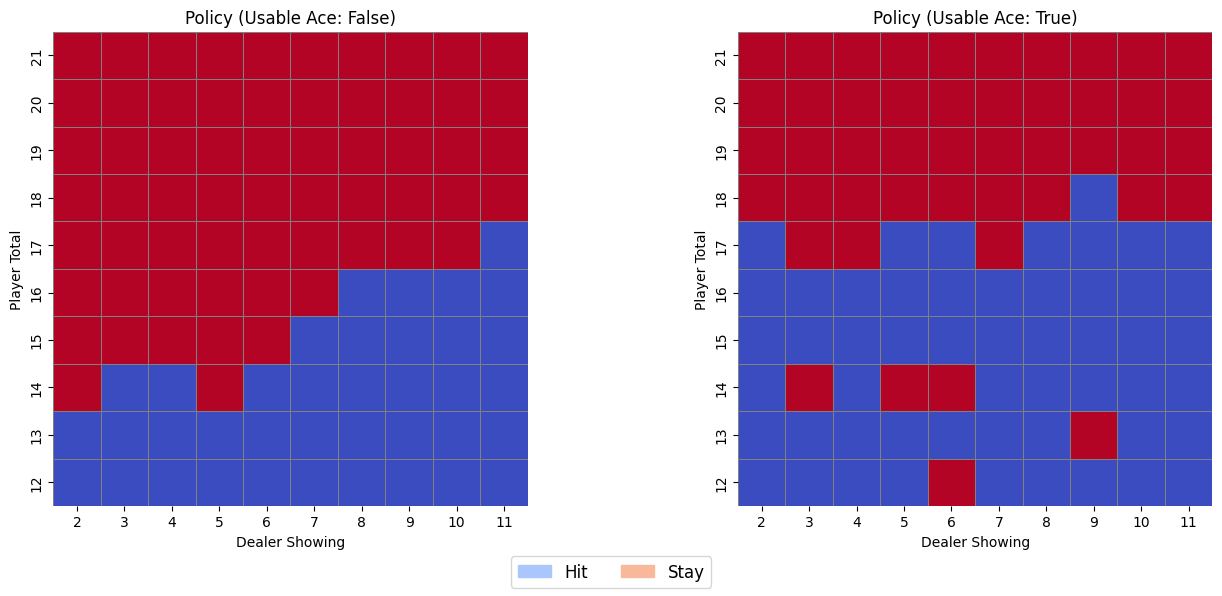


Blackjack Q-Learning Console Menu
1. Play Blackjack
2. Evaluate threshold policy (16) for basic Blackjack
3. Evaluate threshold policy (17) for basic Blackjack
4. Train Agent for basic Blackjack
5. Train Agent for card counting Blackjack
6. Evaluate different count states for card counting Blackjack
7. Exit
Select an option (1-6): 5

Training the agent for card counting Blackjack... This might take a while.
Out of 100000 games:
Wins:  42.48%
Draws: 9.37%
Losses:48.15%


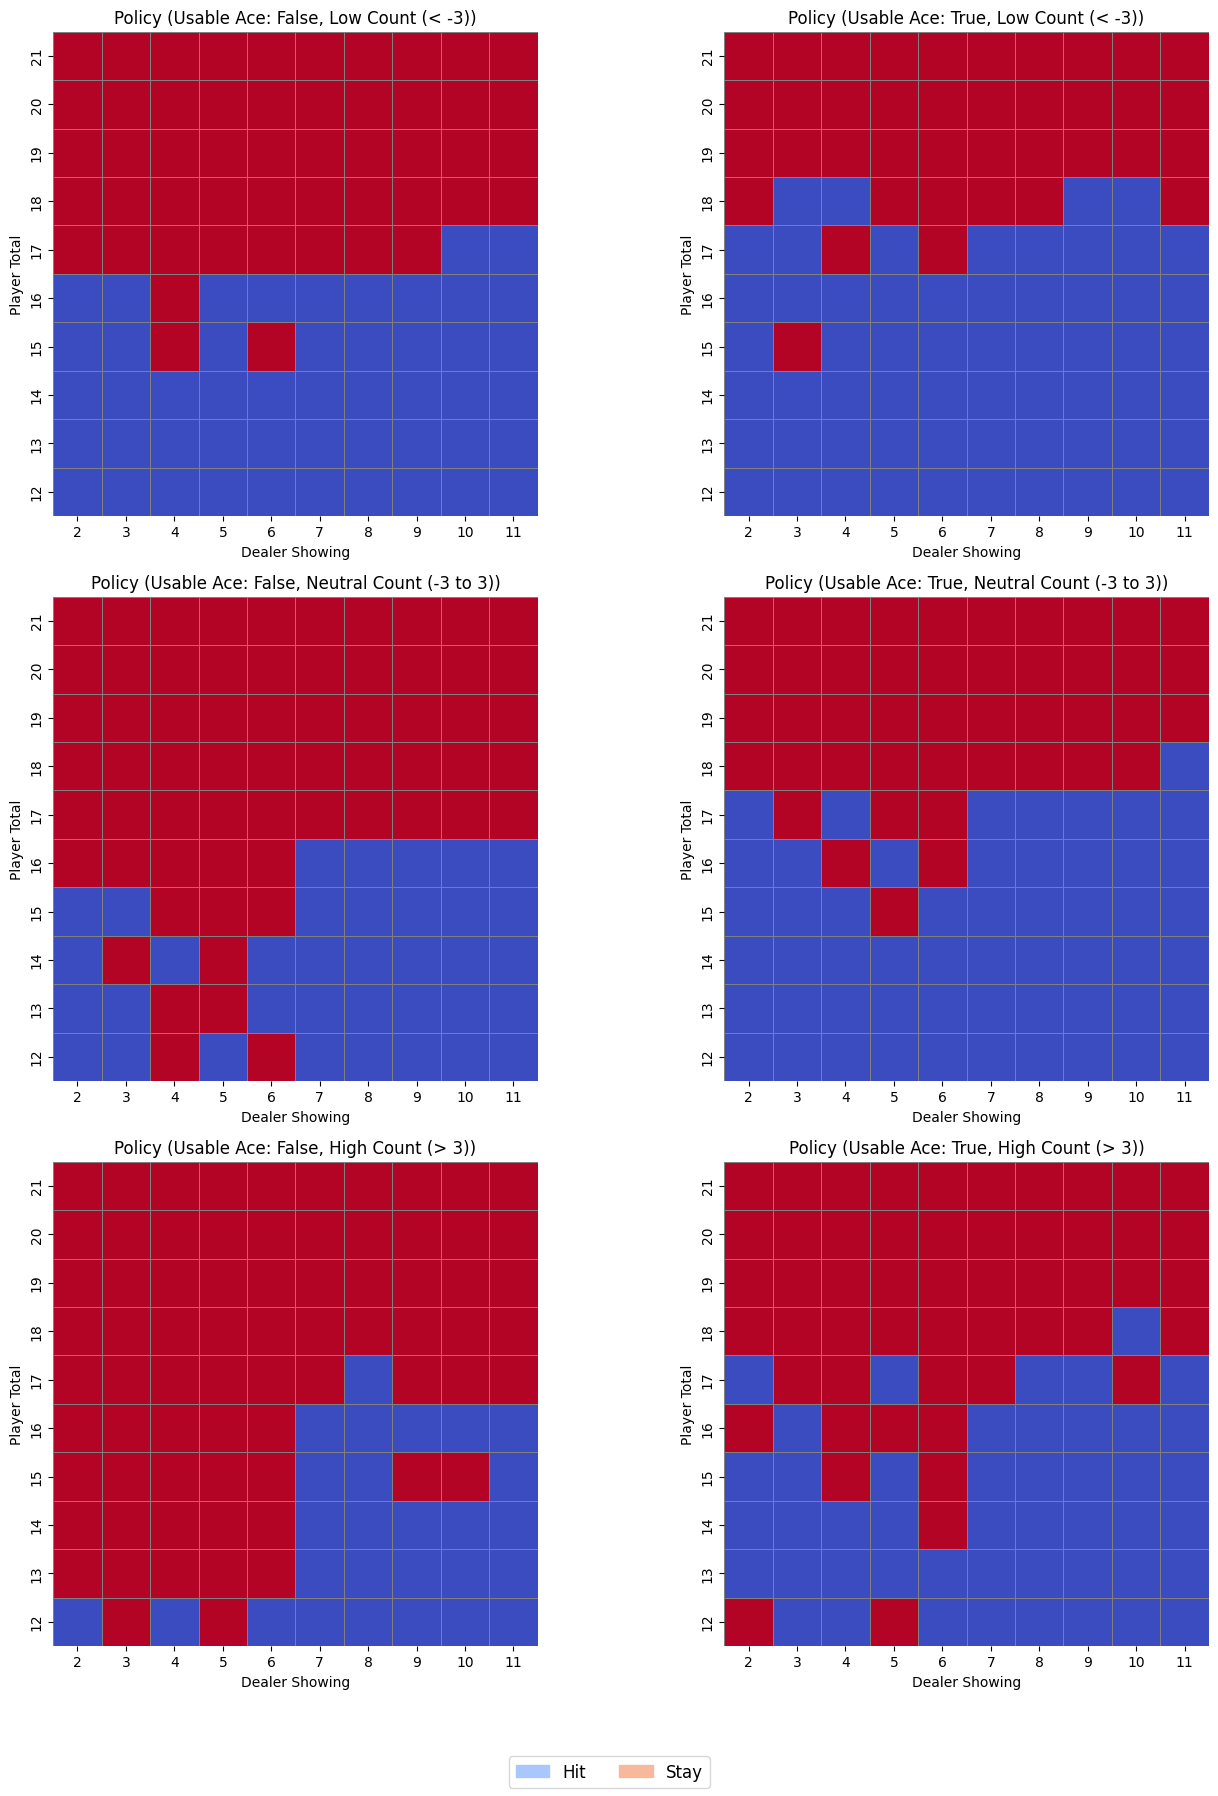


Blackjack Q-Learning Console Menu
1. Play Blackjack
2. Evaluate threshold policy (16) for basic Blackjack
3. Evaluate threshold policy (17) for basic Blackjack
4. Train Agent for basic Blackjack
5. Train Agent for card counting Blackjack
6. Evaluate different count states for card counting Blackjack
7. Exit
Select an option (1-6): 6

Training the agent and evaluating different states for card counting Blackjack... This might take a while.
Out of 11131 games (Low count):
Wins:  46.77%
Draws: 8.80%
Losses:44.43%
Out of 79101 games (Neutral count):
Wins:  41.65%
Draws: 9.55%
Losses:48.80%
Out of 9768 games (High count):
Wins:  40.93%
Draws: 9.08%
Losses:49.99%

Blackjack Q-Learning Console Menu
1. Play Blackjack
2. Evaluate threshold policy (16) for basic Blackjack
3. Evaluate threshold policy (17) for basic Blackjack
4. Train Agent for basic Blackjack
5. Train Agent for card counting Blackjack
6. Evaluate different count states for card counting Blackjack
7. Exit
Select an option (1-6):

SystemExit: 

/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [10]:
import random
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import time
import sys

np.random.seed(42)

CARD_VALUES = {
    "2": 2, "3": 3, "4": 4, "5": 5,
    "6": 6, "7": 7, "8": 8, "9": 9,
    "10": 10, "J": 10, "Q": 10, "K": 10, "A": 11
}
SUITS = ['Hearts', 'Diamonds', 'Clubs', 'Spades']
DECK = [f"{value} of {suit}" for value in CARD_VALUES for suit in SUITS]

#Q-Table
Q = defaultdict(lambda: np.zeros(2)) #0 = Hit, 1 = Stay

########################### PLAY BLACKJACK ON YOUR OWN #############################
#Function to return the value of a card
def get_card_value(card, current_sum):
    value = card.split()[0]
    if value == "A":
        return 11 if current_sum + 11 <= 21 else 1
    return CARD_VALUES[value]

#Function to display the cards
def display_hand(name, hand, hide_first=False):
    if hide_first:
        print(f"{name}'s hand: ['Hidden', '{hand[1]}']")
    else:
        print(f"{name}'s hand: {hand} (Total: {calculate_hand_value(hand)})")

#Function that handles the player's turn
def player_turn(deck, player_hand):
    while True:
        display_hand("Player", player_hand)
        value = calculate_hand_value(player_hand)
        if value > 21:
            print("You busted! Over 21.")
            return value
        elif value == 21:
            print("You hit 21!")
            return value
        choice = input("Do you want to (H)it or (S)tay? ").strip().lower()
        if choice == 'h':
            card = deck.pop()
            print(f"You drew {card}")
            player_hand.append(card)
        elif choice == 's':
            return value
        else:
            print("Invalid choice. Type H or S.")

#Function that handles the dealer's turn
def dealer_turn(deck, dealer_hand):
    print("\nDealer's turn:")
    display_hand("Dealer", dealer_hand)
    while True:
        value = calculate_hand_value(dealer_hand)
        if value == 21:
            print("Dealer has 21!")
            return value
        elif value <= 16:
            print("Dealer hits.")
            card = deck.pop()
            print(f"Dealer drew {card}")
            dealer_hand.append(card)
        elif 17 <= value <= 20:
            print("Dealer stays.")
            return value
        elif value > 21:
            print("Dealer busted!")
            return value

#Function that determines the winner
def determine_winner(player_total, dealer_total):
    if player_total > 21:
        return -1
    elif dealer_total > 21:
        return 1
    elif player_total > dealer_total:
        return 1
    elif player_total < dealer_total:
        return -1
    else:
        return 0

#Function that handles the game logic
def play_blackjack():
    score = 0
    while True:
        deck = DECK.copy()
        random.shuffle(deck)
        player_hand = [deck.pop(), deck.pop()]
        dealer_hand = [deck.pop(), deck.pop()]

        print("\n" + "="*40)
        display_hand("Dealer", dealer_hand, hide_first=True)
        player_total = player_turn(deck, player_hand)

        if player_total <= 21:
            dealer_total = dealer_turn(deck, dealer_hand)
        else:
            dealer_total = calculate_hand_value(dealer_hand)

        print("\nFinal hands:")
        display_hand("Player", player_hand)
        display_hand("Dealer", dealer_hand)

        result = determine_winner(player_total, dealer_total)
        if result == 1:
            print("You win!")
            score += 1
        elif result == -1:
            print("You lose!")
            score -= 1
        else:
            print("It's a draw.")

        print(f"Score: {score}")
        again = input("\nPlay again? (y/n): ").strip().lower()
        if again != 'y':
            break
##########################################################################

########################### USEFUL FUNCTIONS #############################
#Function that calculates the hand sum
def calculate_hand_value(hand):
    total = 0
    aces = 0
    for card in hand:
        value = card.split()[0]
        if value == "A":
            aces += 1
        else:
            total += CARD_VALUES[value]
    for _ in range(aces):
        total += 11 if total + 11 <= 21 else 1
    return total

#Function that calculates the dealer hand sum
def calculate_dealer_hand_value(hand):
    total = 0
    aces = 0
    for card in hand:
        value = card.split()[0]
        if value == "A":
            aces += 1
        else:
            total += CARD_VALUES[value]
    for _ in range(aces):
        total += 11 if 17 <= total + 11 <= 21 else 1 #If the dealer's hand is between 17 and 21 with an Ace turn to 11 it must stay this way
    return total

########################### BASIC BLACKJACK FUNCTIONS ####################
#Function that returns the state
def get_state_basic(player_hand, dealer_card):
    total = calculate_hand_value(player_hand)
    usable_ace = 1 if any(card.startswith("A") and calculate_hand_value(player_hand) <= 21 for card in player_hand) else 0
    value = dealer_card.split()[0]
    dealer_value = 11 if value == "A" else CARD_VALUES[value]
    return (total, dealer_value, usable_ace)

#Function that chooses the action to be performed
def choose_action(state, epsilon):
    if np.random.rand() < epsilon:
        return np.random.choice([0, 1])
    return np.argmax(Q[state])

#Function that handles the dealer's turn
def play_dealer_basic(deck, dealer_hand):
    while calculate_dealer_hand_value(dealer_hand) < 17:
        dealer_hand.append(deck.pop())
    return calculate_dealer_hand_value(dealer_hand)

#Q-Learning Training basic
def Q_learning_basic():
  EPISODES = 2_000_000
  alpha = 0.05 #Constant learning rate
  gamma = 1 #Discount isn't needed
  epsilon = 1.0
  min_epsilon = 0.005 #E-greedy with epsilon starting from 1 and linearly decreasing to min_epsilon during the entire training phase
  decay = 0.99999 #rate with which exploration is decreased

  for episode in range(EPISODES):
      deck = DECK.copy()
      random.shuffle(deck)

      player_hand = [deck.pop(), deck.pop()]
      dealer_hand = [deck.pop(), deck.pop()]
      dealer_card = dealer_hand[1]

      state = get_state_basic(player_hand, dealer_card)
      done = False

      while not done:
          action = choose_action(state, epsilon)
          if action == 0: #hit action
              player_hand.append(deck.pop())
              new_state = get_state_basic(player_hand, dealer_card)
              player_total = calculate_hand_value(player_hand)
              if player_total > 21:
                  reward = -1
                  done = True
              else:
                  reward = 0
          else: #stay action
              done = True
              player_total = calculate_hand_value(player_hand)
              dealer_total = play_dealer_basic(deck, dealer_hand)
              if dealer_total > 21 or player_total > dealer_total:
                  reward = 1
              elif player_total < dealer_total:
                  reward = -1
              else:
                  reward = 0
              new_state = None

          if not done: #Q-learning formula from the literature for non-terminal states
              Q[state][action] += alpha * (reward + gamma * np.max(Q[new_state]) - Q[state][action])
              state = new_state
          else: #Q-learning formula from the literature for terminal states
              Q[state][action] += alpha * (reward - Q[state][action])

      epsilon = max(min_epsilon, epsilon * decay) #minimum exploration is 0.5% (practically 0)

  return Q

#Evaluation of learned policy of basic
def evaluate_policy_basic(episodes=100000):
    wins = draws = losses = 0
    for episode in range(episodes):
        deck = DECK.copy()
        random.shuffle(deck)
        player_hand = [deck.pop(), deck.pop()]
        dealer_hand = [deck.pop(), deck.pop()]
        dealer_card = dealer_hand[1]
        state = get_state_basic(player_hand, dealer_card)

        while True:
            action = np.argmax(Q[state])
            if action == 0: #hit action
                new_card = deck.pop()
                player_hand.append(new_card)
                state = get_state_basic(player_hand, dealer_card)
                if calculate_hand_value(player_hand) > 21:
                    losses += 1
                    break
            else: #stay action
                break

        if calculate_hand_value(player_hand) <= 21:
            player_total = calculate_hand_value(player_hand)
            dealer_total = play_dealer_basic(deck, dealer_hand)
            if dealer_total > 21 or player_total > dealer_total:
                wins += 1
            elif player_total < dealer_total:
                losses += 1
            else:
                draws += 1

    print(f"Out of {wins + losses + draws} games:")
    print(f"Wins:  {wins / episodes:.2%}")
    print(f"Draws: {draws / episodes:.2%}")
    print(f"Losses:{losses / episodes:.2%}")

#Plot policy function for basic
def plot_policy_basic(Q):
    def get_policy(usable_ace):
        policy = np.zeros((10, 10))  #player 12-21, dealer 2-11
        for player_total in range(12, 22):
            for dealer_card in range(2, 12):
                state = (player_total, dealer_card, int(usable_ace))
                if state in Q:
                    action = np.argmax(Q[state])
                else:
                    action = 0  #hit action
                policy[player_total - 12, dealer_card - 2] = action
        return policy

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for i, usable_ace in enumerate([False, True]):
        policy = get_policy(usable_ace)
        ax = axes[i]
        sns.heatmap(policy,
                    cmap='coolwarm',  #0 = hit (blue), 1 = stay (red)
                    xticklabels=range(2, 12),
                    yticklabels=range(12, 22),
                    cbar=False,
                    ax=ax,
                    linewidths=.5,
                    linecolor='gray',
                    square=True)
        ax.set_title(f'Policy (Usable Ace: {usable_ace})')
        ax.set_xlabel('Dealer Showing')
        ax.set_ylabel('Player Total')
        ax.invert_yaxis()

    hit_patch = mpatches.Patch(color=sns.color_palette("coolwarm", 2)[0], label='Hit')
    stay_patch = mpatches.Patch(color=sns.color_palette("coolwarm", 2)[1], label='Stay')
    fig.legend(handles=[hit_patch, stay_patch], loc='lower center', ncol=2, fontsize='large')

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()
##########################################################################

########################### CARD COUNTING BLACKJACK FUNCTIONS ####################
#Function that returns the count state (1 -> High, 0 -> Neutral, -1 -> Low)
def calculate_count_state(count):
    if count > 3:
      return 1
    elif count < -3:
      return -1
    else:
      return 0

#Function that calculates the initial hands' count
def calculate_count(player_hand, dealer_card, count):
    player_card_values = [CARD_VALUES[card.split()[0]] for card in player_hand]
    for i in range(len(player_card_values)):
      if 2 <= player_card_values[i] <= 6:
        count += 1
      elif 10 <= player_card_values[i] <= 11:
        count -= 1

    dealer_card_value = CARD_VALUES[dealer_card.split()[0]]
    if 2 <= dealer_card_value <= 6:
        count += 1
    elif 10 <= dealer_card_value <= 11:
        count -= 1

    return count

#Function that returns the state
def get_state_card_counting(player_hand, dealer_card, count):
    total = calculate_hand_value(player_hand)
    usable_ace = 1 if any(card.startswith("A") and calculate_hand_value(player_hand) <= 21 for card in player_hand) else 0
    value = dealer_card.split()[0]
    dealer_value = 11 if value == "A" else CARD_VALUES[value]
    count_state = calculate_count_state(count)
    return (total, dealer_value, usable_ace, count_state)

#Function that handles the dealer's turn
def play_dealer_card_counting(deck, dealer_hand, count):
    while calculate_dealer_hand_value(dealer_hand) < 17:
        if len(deck) == 0: #Every time the deck is empty, we get a new shuffled deck and reset the card count
            deck = DECK.copy()
            random.shuffle(deck)
            count = 0

        dealer_new_card = deck.pop()
        dealer_hand.append(dealer_new_card)

        dealer_new_card_value = CARD_VALUES[dealer_new_card.split()[0]]
        if 2 <= dealer_new_card_value <= 6:
            count += 1
        elif 10 <= dealer_new_card_value <= 11:
            count -= 1
    return calculate_dealer_hand_value(dealer_hand), count, deck

#Q-Learning Training for card counting
def Q_learning_card_counting():
  EPISODES = 6_000_000 #number of episodes is tripled because the state space is tripled
  alpha = 0.05
  gamma = 1
  epsilon = 1.0
  min_epsilon = 0.005
  decay = 0.999999

  deck = DECK.copy()
  random.shuffle(deck)
  count = 0

  for episode in range(EPISODES):
      if len(deck) <= 10: #Every time we have 10 or less cards we re-shuffle
        deck = DECK.copy()
        random.shuffle(deck)
        count = 0

      player_hand = [deck.pop(), deck.pop()]
      dealer_hand = [deck.pop(), deck.pop()]
      dealer_card = dealer_hand[1]

      count = calculate_count(player_hand, dealer_card, count)

      state = get_state_card_counting(player_hand, dealer_card, count)
      done = False

      while not done:
          action = choose_action(state, epsilon)
          if action == 0: #hit action
              player_new_card = deck.pop()
              player_hand.append(player_new_card)
              player_new_card_value = CARD_VALUES[player_new_card.split()[0]]
              if 2 <= player_new_card_value <= 6:
                  count += 1
              elif 10 <= player_new_card_value <= 11:
                  count -= 1

              new_state = get_state_card_counting(player_hand, dealer_card, count)
              player_total = calculate_hand_value(player_hand)
              if player_total > 21:
                  reward = -1
                  done = True
              else:
                  reward = 0
          else: #stay action
              done = True
              player_total = calculate_hand_value(player_hand)
              dealer_total, count, deck = play_dealer_card_counting(deck, dealer_hand, count)
              if dealer_total > 21 or player_total > dealer_total:
                  reward = 1
              elif player_total < dealer_total:
                  reward = -1
              else:
                  reward = 0
              new_state = None

          if not done:
              Q[state][action] += alpha * (reward + gamma * np.max(Q[new_state]) - Q[state][action])
              state = new_state
          else:
              Q[state][action] += alpha * (reward - Q[state][action])

      epsilon = max(min_epsilon, epsilon * decay)

  return Q

#Evaluation of learned policy of card counting
def evaluate_policy_card_counting(episodes=100000):
    deck = DECK.copy()
    random.shuffle(deck)
    count = 0
    wins = draws = losses = 0
    for _ in range(episodes):
        if len(deck) <= 10:
            deck = DECK.copy()
            random.shuffle(deck)
            count = 0
        player_hand = [deck.pop(), deck.pop()]
        dealer_hand = [deck.pop(), deck.pop()]
        dealer_card = dealer_hand[1]
        count = calculate_count(player_hand, dealer_card, count)

        state = get_state_card_counting(player_hand, dealer_card, count)

        while True:
            action = np.argmax(Q[state])
            if action == 0:  #hit action
                player_new_card = deck.pop()
                player_hand.append(player_new_card)
                player_new_card_value = CARD_VALUES[player_new_card.split()[0]]
                if 2 <= player_new_card_value <= 6:
                    count += 1
                elif 10 <= player_new_card_value <= 11:
                    count -= 1

                state = get_state_card_counting(player_hand, dealer_card, count)
                if calculate_hand_value(player_hand) > 21:
                    losses += 1
                    break
            else:  #stay action
                break

        if calculate_hand_value(player_hand) <= 21:
            player_total = calculate_hand_value(player_hand)
            dealer_total, count, deck = play_dealer_card_counting(deck, dealer_hand, count)
            if dealer_total > 21 or player_total > dealer_total:
                wins += 1
            elif player_total < dealer_total:
                losses += 1
            else:
                draws += 1

    print(f"Out of {wins + losses + draws} games:")
    print(f"Wins:  {wins / episodes:.2%}")
    print(f"Draws: {draws / episodes:.2%}")
    print(f"Losses:{losses / episodes:.2%}")

#Evaluation of learned policy of card counting for Low, Neutral and High separately
def evaluate_policy_card_counting_Low_Neutral_High(episodes=100000):
    deck = DECK.copy()
    random.shuffle(deck)
    count = 0
    wins_l = draws_l = losses_l = 0
    wins_n = draws_n = losses_n = 0
    wins_h = draws_h = losses_h = 0

    episodes_l = episodes_n = episodes_h = 0

    for _ in range(episodes):
        if len(deck) <= 10:
            deck = DECK.copy()
            random.shuffle(deck)
            count = 0
        player_hand = [deck.pop(), deck.pop()]
        dealer_hand = [deck.pop(), deck.pop()]
        dealer_card = dealer_hand[1]
        count = calculate_count(player_hand, dealer_card, count)

        state = get_state_card_counting(player_hand, dealer_card, count)

        while True:
            action = np.argmax(Q[state])
            if action == 0:  #hit action
                player_new_card = deck.pop()
                player_hand.append(player_new_card)
                player_new_card_value = CARD_VALUES[player_new_card.split()[0]]
                if 2 <= player_new_card_value <= 6:
                    count += 1
                elif 10 <= player_new_card_value <= 11:
                    count -= 1

                state = get_state_card_counting(player_hand, dealer_card, count)
                if calculate_hand_value(player_hand) > 21:
                  if calculate_count_state(count) == -1:
                    losses_l += 1
                    episodes_l += 1
                    break
                  elif calculate_count_state(count) == 0:
                    losses_n += 1
                    episodes_n += 1
                    break
                  else:
                    losses_h += 1
                    episodes_h += 1
                    break
            else:  #stay action
                break

        if calculate_hand_value(player_hand) <= 21:
            player_total = calculate_hand_value(player_hand)
            dealer_total, count, deck = play_dealer_card_counting(deck, dealer_hand, count)
            if dealer_total > 21 or player_total > dealer_total:
                if calculate_count_state(count) == -1:
                  wins_l += 1
                  episodes_l += 1
                elif calculate_count_state(count) == 0:
                  wins_n += 1
                  episodes_n += 1
                else:
                  wins_h += 1
                  episodes_h += 1
            elif player_total < dealer_total:
                if calculate_count_state(count) == -1:
                  losses_l += 1
                  episodes_l += 1
                elif calculate_count_state(count) == 0:
                  losses_n += 1
                  episodes_n += 1
                else:
                  losses_h += 1
                  episodes_h += 1
            else:
                if calculate_count_state(count) == -1:
                  draws_l += 1
                  episodes_l += 1
                elif calculate_count_state(count) == 0:
                  draws_n += 1
                  episodes_n += 1
                else:
                  draws_h += 1
                  episodes_h += 1

    print(f"Out of {wins_l + losses_l + draws_l} games (Low count):")
    print(f"Wins:  {wins_l / episodes_l:.2%}")
    print(f"Draws: {draws_l / episodes_l:.2%}")
    print(f"Losses:{losses_l / episodes_l:.2%}")

    print(f"Out of {wins_n + losses_n + draws_n} games (Neutral count):")
    print(f"Wins:  {wins_n / episodes_n:.2%}")
    print(f"Draws: {draws_n / episodes_n:.2%}")
    print(f"Losses:{losses_n / episodes_n:.2%}")

    print(f"Out of {wins_h + losses_h + draws_h} games (High count):")
    print(f"Wins:  {wins_h / episodes_h:.2%}")
    print(f"Draws: {draws_h / episodes_h:.2%}")
    print(f"Losses:{losses_h / episodes_h:.2%}")

#Plot policy function for card counting
def plot_policy_card_counting(Q):
    def get_policy(usable_ace, count_state):
        policy = np.zeros((10, 10))  #player total 12-21, dealer 2-11
        for player_total in range(12, 22):
            for dealer_card in range(2, 12):
                state = (player_total, dealer_card, int(usable_ace), count_state)
                if state in Q:
                    action = np.argmax(Q[state])
                else:
                    action = 0  #hit action
                policy[player_total - 12, dealer_card - 2] = action
        return policy

    fig, axes = plt.subplots(3, 2, figsize=(14, 18))

    count_labels = ['Low Count (< -3)', 'Neutral Count (-3 to 3)', 'High Count (> 3)']

    for ci, count_state in enumerate([-1, 0, 1]):
        for i, usable_ace in enumerate([False, True]):
            policy = get_policy(usable_ace, count_state)
            ax = axes[ci, i]
            sns.heatmap(policy,
                        cmap='coolwarm',  # 0 = hit (blue), 1 = stay (red)
                        xticklabels=range(2, 12),
                        yticklabels=range(12, 22),
                        cbar=False,
                        ax=ax,
                        linewidths=.5,
                        linecolor='gray',
                        square=True)
            ax.set_title(f'Policy (Usable Ace: {usable_ace}, {count_labels[ci]})')
            ax.set_xlabel('Dealer Showing')
            ax.set_ylabel('Player Total')
            ax.invert_yaxis()

    hit_patch = mpatches.Patch(color=sns.color_palette("coolwarm", 2)[0], label='Hit')
    stay_patch = mpatches.Patch(color=sns.color_palette("coolwarm", 2)[1], label='Stay')
    fig.legend(handles=[hit_patch, stay_patch], loc='lower center', ncol=2, fontsize='large')

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()
##########################################################################

########################### SIMPLE BASELINE POLICIES (HIT WHEN UNDER 'threshold') ####################
#Threshold policy evaluation: Always hit < 16, stay >= 16
def evaluate_threshold_16_policy(episodes=100000):
    wins = draws = losses = 0
    for _ in range(episodes):
        deck = DECK.copy()
        random.shuffle(deck)
        player_hand = [deck.pop(), deck.pop()]
        dealer_hand = [deck.pop(), deck.pop()]

        #player strategy: hit if value <= 15, otherwise stay
        while calculate_hand_value(player_hand) <= 15:
            player_hand.append(deck.pop())

        player_total = calculate_hand_value(player_hand)
        if player_total > 21:
            losses += 1
            continue

        dealer_total = play_dealer_basic(deck, dealer_hand)
        if dealer_total > 21 or player_total > dealer_total:
            wins += 1
        elif player_total < dealer_total:
            losses += 1
        else:
            draws += 1

    print(f"Out of {wins + losses + draws} games:")
    print(f"Wins:  {wins / episodes:.2%}")
    print(f"Draws: {draws / episodes:.2%}")
    print(f"Losses:{losses / episodes:.2%}")

#Threshold policy evaluation: Always hit < 17, stay >= 17
def evaluate_threshold_17_policy(episodes=100000):
    wins = draws = losses = 0
    for _ in range(episodes):
        deck = DECK.copy()
        random.shuffle(deck)
        player_hand = [deck.pop(), deck.pop()]
        dealer_hand = [deck.pop(), deck.pop()]

        #player strategy: hit if value <= 16, otherwise stay
        while calculate_hand_value(player_hand) <= 16:
            player_hand.append(deck.pop())

        player_total = calculate_hand_value(player_hand)
        if player_total > 21:
            losses += 1
            continue

        dealer_total = play_dealer_basic(deck, dealer_hand)
        if dealer_total > 21 or player_total > dealer_total:
            wins += 1
        elif player_total < dealer_total:
            losses += 1
        else:
            draws += 1

    print(f"Out of {wins + losses + draws} games:")
    print(f"Wins:  {wins / episodes:.2%}")
    print(f"Draws: {draws / episodes:.2%}")
    print(f"Losses:{losses / episodes:.2%}")
##########################################################################

def main_menu():
    while True:
        print("\n" + "="*40)
        print("Blackjack Q-Learning Console Menu")
        print("="*40)
        print("1. Play Blackjack")
        print("2. Evaluate threshold policy (16) for basic Blackjack")
        print("3. Evaluate threshold policy (17) for basic Blackjack")
        print("4. Train Agent for basic Blackjack")
        print("5. Train Agent for card counting Blackjack")
        print("6. Evaluate different count states for card counting Blackjack")
        print("7. Exit")
        print("="*40)

        choice = input("Select an option (1-7): ").strip()

        if choice == '1': #Play on your own
            play_blackjack()
        elif choice == '2': #Evaluate a simple threshold (16) policy
            print("\nEvaluating a simple threshold (16) policy for basic Blackjack...")
            evaluate_threshold_16_policy()
        elif choice == '3': #Evaluate a simple threshold (17) policy
            print("\nEvaluating a simple threshold (17) policy for basic Blackjack...")
            evaluate_threshold_17_policy()
        elif choice == '4': #Train for basic Blackjack
            print("\nTraining the agent for basic Blackjack... This might take a while.")
            Q_learning_basic()
            evaluate_policy_basic()
            plot_policy_basic(Q)
            time.sleep(1)
        elif choice == '5': #Train for card counting Blackjack
            print("\nTraining the agent for card counting Blackjack... This might take a while.")
            Q_learning_card_counting()
            evaluate_policy_card_counting()
            plot_policy_card_counting(Q)
            time.sleep(2)
        elif choice == '6': #Evaluate different count states for card counting Blackjack
            print("\nTraining the agent and evaluating different states for card counting Blackjack... This might take a while.")
            Q_learning_card_counting()
            evaluate_policy_card_counting_Low_Neutral_High()
            time.sleep(2)
        elif choice == '7': #Exit
            print("\nThanks for playing! Goodbye")
            time.sleep(1)
            sys.exit()
        else:
            print("\nInvalid input. Please enter a number from 1 to 4.")
            time.sleep(1)


if __name__ == "__main__":
    main_menu()
